In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv("/content/flight_data_2024.csv")
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0.0,136.0,122.0,84.0,509.0,0.0,0.0,0.0,0.0,0.0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0.0,130.0,114.0,88.0,622.0,0.0,0.0,0.0,0.0,0.0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0.0,106.0,90.0,61.0,288.0,0.0,0.0,0.0,0.0,0.0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0.0,111.0,76.0,51.0,288.0,0.0,0.0,0.0,0.0,0.0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0.0,79.0,70.0,45.0,237.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.tail()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
17050,2024,1,1,1,2024-01-01,YX,4457.0,DCA,"Washington, DC",Virginia,...,0.0,77.0,73.0,48.0,227.0,0.0,0.0,0.0,0.0,0.0
17051,2024,1,1,1,2024-01-01,YX,4457.0,RDU,"Raleigh/Durham, NC",North Carolina,...,0.0,75.0,73.0,44.0,227.0,0.0,0.0,0.0,0.0,0.0
17052,2024,1,1,1,2024-01-01,YX,4458.0,RDU,"Raleigh/Durham, NC",North Carolina,...,0.0,76.0,54.0,37.0,227.0,0.0,0.0,0.0,0.0,0.0
17053,2024,1,1,1,2024-01-01,YX,4462.0,ORD,"Chicago, IL",Illinois,...,0.0,101.0,105.0,85.0,528.0,0.0,0.0,0.0,0.0,0.0
17054,2024,1,1,1,2024-01-01,YX,4462.0,ROC,"Rochester, NY",New York,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17055 entries, 0 to 17054
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 17055 non-null  int64  
 1   month                17055 non-null  int64  
 2   day_of_month         17055 non-null  int64  
 3   day_of_week          17055 non-null  int64  
 4   fl_date              17055 non-null  object 
 5   op_unique_carrier    17055 non-null  object 
 6   op_carrier_fl_num    17055 non-null  float64
 7   origin               17055 non-null  object 
 8   origin_city_name     17055 non-null  object 
 9   origin_state_nm      17055 non-null  object 
 10  dest                 17055 non-null  object 
 11  dest_city_name       17055 non-null  object 
 12  dest_state_nm        17055 non-null  object 
 13  crs_dep_time         17055 non-null  int64  
 14  dep_time             17040 non-null  float64
 15  dep_delay            17040 non-null 

In [7]:
df.shape

(17055, 35)

In [8]:
df.dtypes

,0
year,int64
month,int64
day_of_month,int64
day_of_week,int64
fl_date,object
op_unique_carrier,object
op_carrier_fl_num,float64
origin,object
origin_city_name,object
origin_state_nm,object


In [9]:
df.isnull().sum()

,0
year,0
month,0
day_of_month,0
day_of_week,0
fl_date,0
op_unique_carrier,0
op_carrier_fl_num,0
origin,0
origin_city_name,0
origin_state_nm,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print("Mean of Numerical Features:\n")
df.select_dtypes(include=['int64', 'float64']).mean()

Mean of Numerical Features:



,0
year,2024.000000
month,1.000000
day_of_month,1.000000
day_of_week,1.000000
op_carrier_fl_num,2215.465553
crs_dep_time,1346.069774
dep_time,1345.256925
dep_delay,5.426115
taxi_out,16.841237
wheels_off,1366.133995


In [12]:
print("Median of Numerical Features:\n")
df.select_dtypes(include=['int64', 'float64']).median()

Median of Numerical Features:



,0
year,2024.0
month,1.0
day_of_month,1.0
day_of_week,1.0
op_carrier_fl_num,1983.0
crs_dep_time,1335.0
dep_time,1336.0
dep_delay,-3.0
taxi_out,15.0
wheels_off,1348.0


In [13]:
print("Mode of Numerical Features:\n")
df.select_dtypes(include=['int64', 'float64']).mode().iloc[0]

Mode of Numerical Features:



,0
year,2024.0
month,1.0
day_of_month,1.0
day_of_week,1.0
op_carrier_fl_num,649.0
crs_dep_time,600.0
dep_time,555.0
dep_delay,-5.0
taxi_out,12.0
wheels_off,611.0


In [14]:
print("Standard Deviation:\n")
df.select_dtypes(include=['int64', 'float64']).std()

Standard Deviation:



,0
year,0.000000
month,0.000000
day_of_month,0.000000
day_of_week,0.000000
op_carrier_fl_num,1512.521158
crs_dep_time,493.733803
dep_time,500.985344
dep_delay,43.429495
taxi_out,7.764689
wheels_off,502.789012


In [15]:
df.describe(percentiles=[0.01,0.05,0.25,0.50,0.75,0.95,0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
year,17055.0,2024.000000,0.000000,2024.0,2024.00,2024.0,2024.0,2024.0,2024.0,2024.00,2024.00,2024.0
month,17055.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.00,1.00,1.0
day_of_month,17055.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.00,1.00,1.0
day_of_week,17055.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.00,1.00,1.0
op_carrier_fl_num,17055.0,2215.465553,1512.521158,1.0,52.00,277.0,1011.0,1983.0,3187.0,5296.60,5667.46,8785.0
crs_dep_time,17055.0,1346.069774,493.733803,8.0,516.00,600.0,925.0,1335.0,1746.0,2130.00,2259.00,2359.0
dep_time,17040.0,1345.256925,500.985344,1.0,510.00,600.0,926.0,1336.0,1752.0,2134.00,2301.61,2400.0
dep_delay,17040.0,5.426115,43.429495,-28.0,-14.00,-10.0,-6.0,-3.0,3.0,42.00,132.00,1403.0
taxi_out,17038.0,16.841237,7.764689,1.0,7.00,9.0,12.0,15.0,20.0,32.00,44.00,99.0
wheels_off,17038.0,1366.133995,502.789012,1.0,516.00,616.0,940.0,1348.0,1806.0,2147.00,2308.00,2400.0


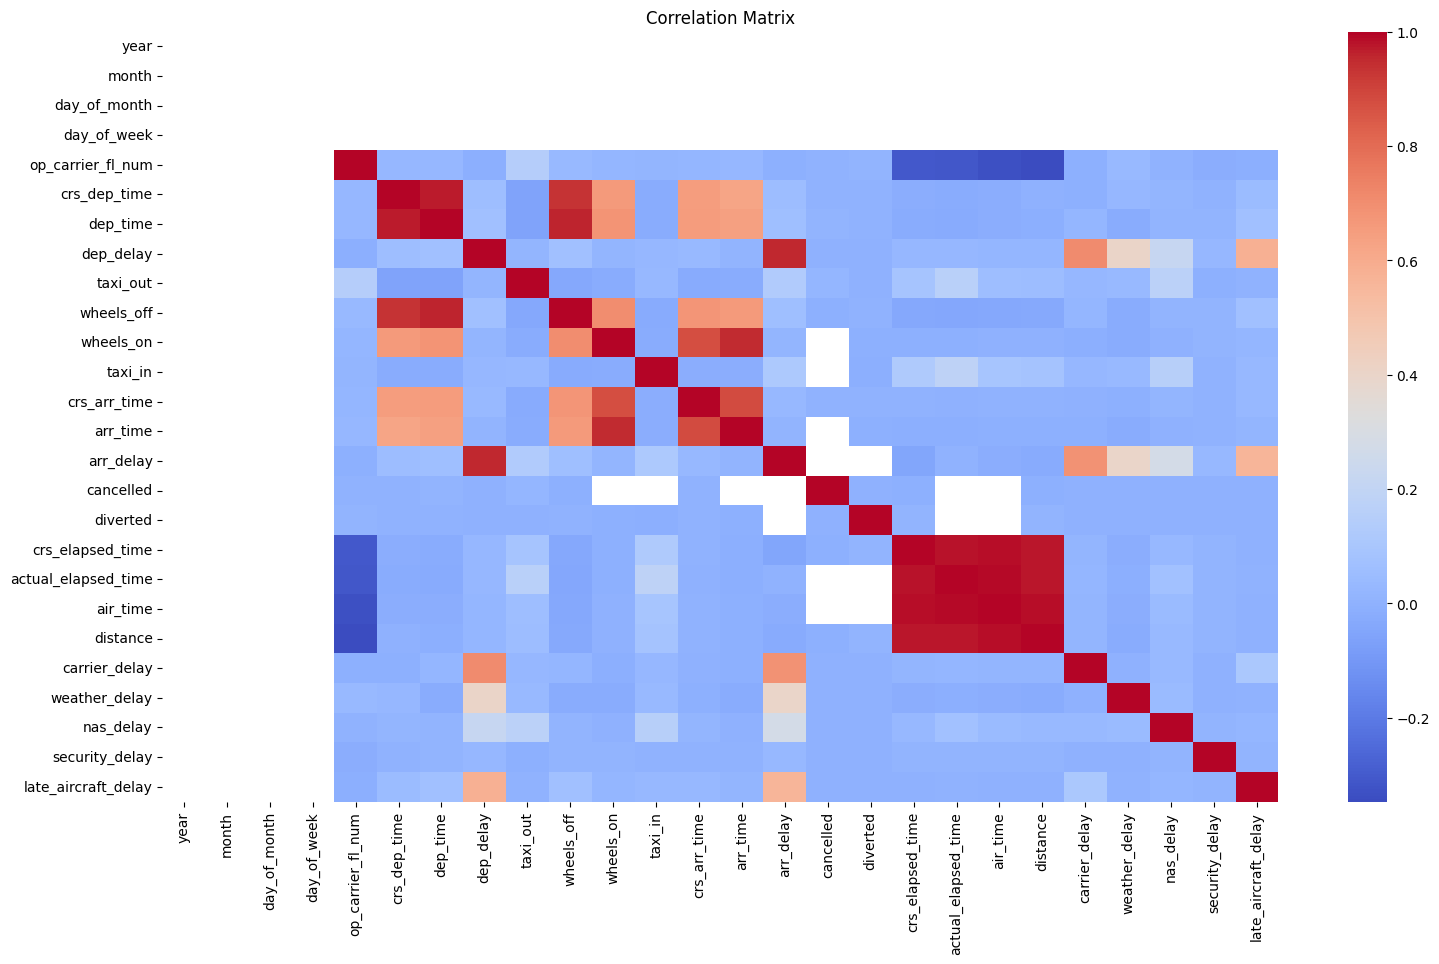

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(18,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [17]:
df['Delayed'] = np.where(df['dep_delay'] > 15, 1, 0)

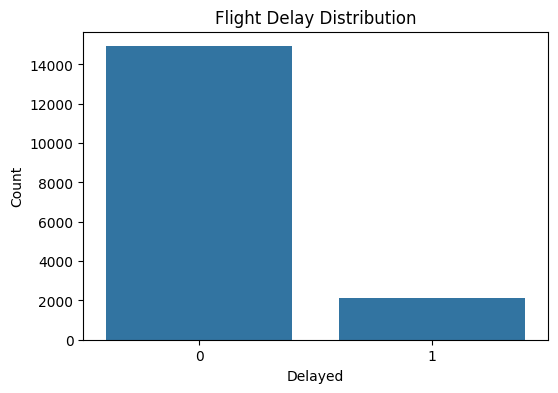

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Delayed'
)

plt.title("Flight Delay Distribution")

plt.xlabel("Delayed")

plt.ylabel("Count")

plt.show()

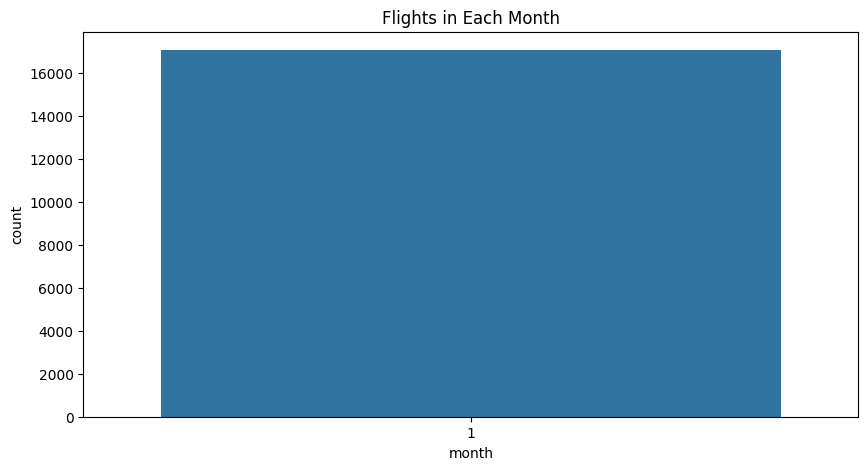

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='month'
)

plt.title("Flights in Each Month")

plt.show()

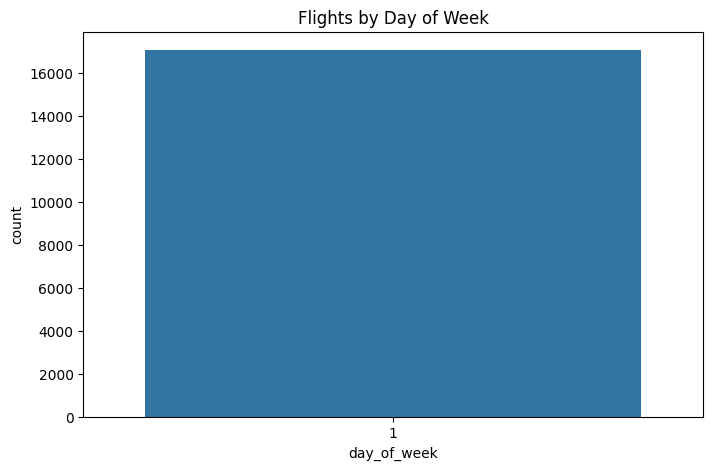

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='day_of_week'
)

plt.title("Flights by Day of Week")

plt.show()

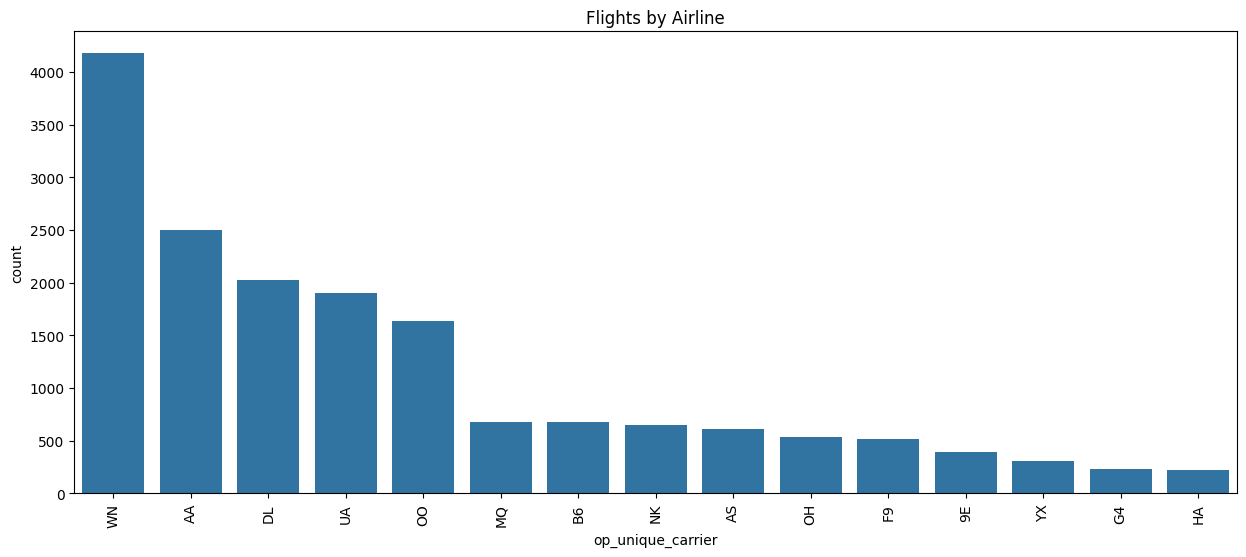

In [21]:
plt.figure(figsize=(15,6))

sns.countplot(
    data=df,
    x='op_unique_carrier',
    order=df['op_unique_carrier'].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Flights by Airline")

plt.show()

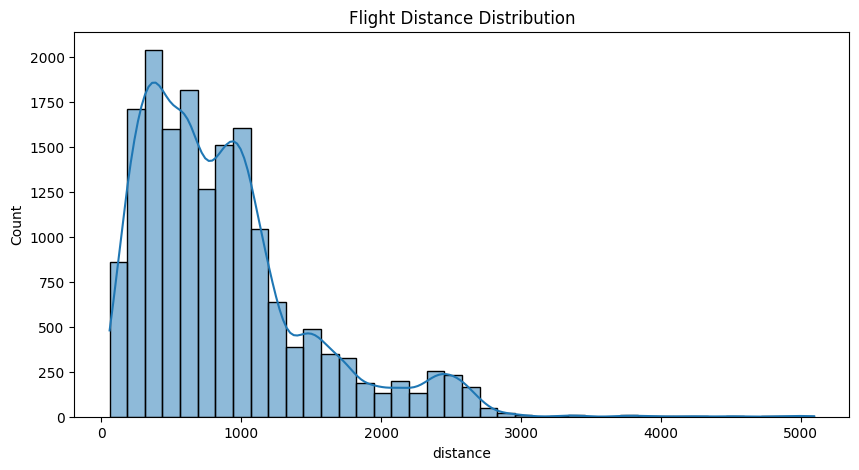

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['distance'],
    bins=40,
    kde=True
)

plt.title("Flight Distance Distribution")

plt.show()

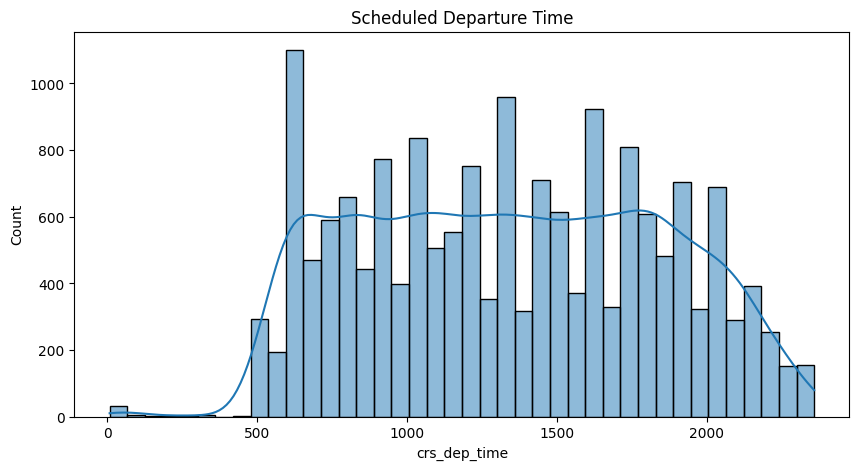

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['crs_dep_time'],
    bins=40,
    kde=True
)

plt.title("Scheduled Departure Time")

plt.show()

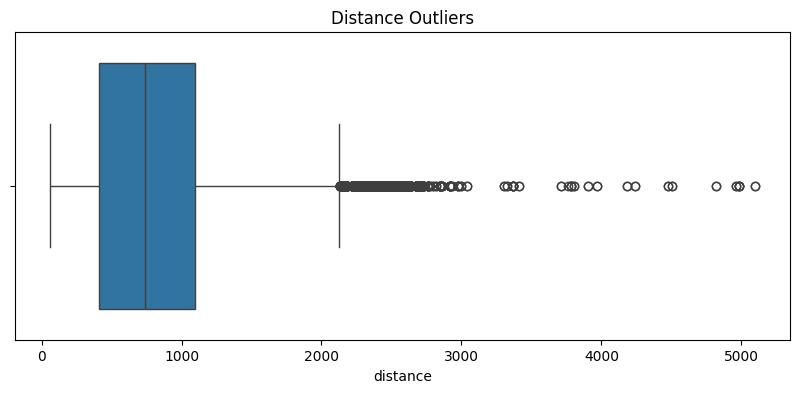

In [24]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['distance']
)

plt.title("Distance Outliers")

plt.show()

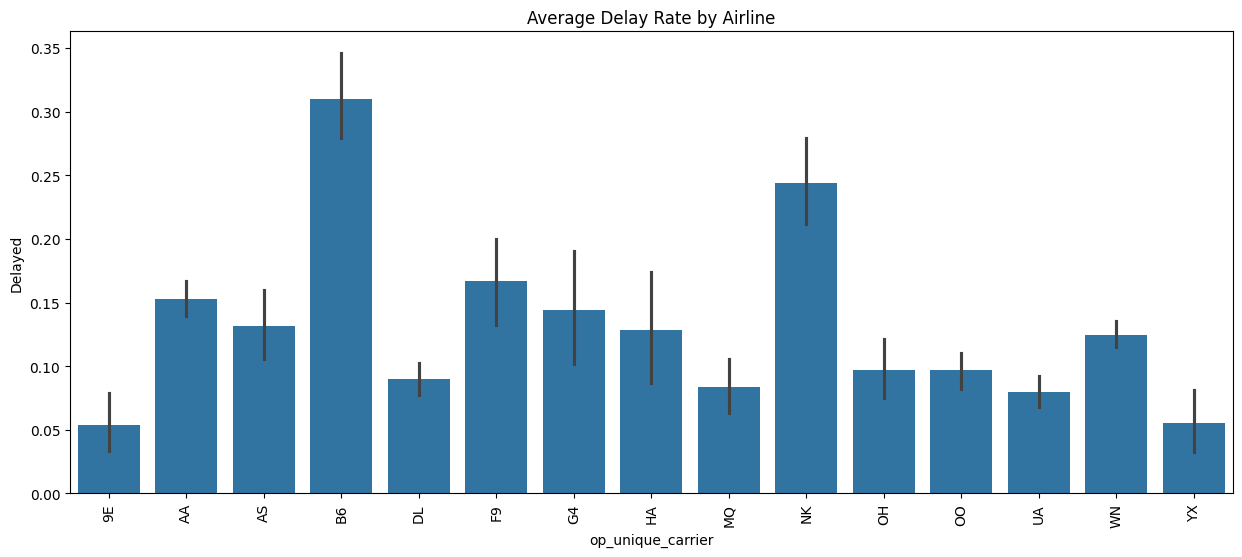

In [25]:
plt.figure(figsize=(15,6))

sns.barplot(
    data=df,
    x='op_unique_carrier',
    y='Delayed',
    estimator=np.mean
)

plt.xticks(rotation=90)

plt.title("Average Delay Rate by Airline")

plt.show()

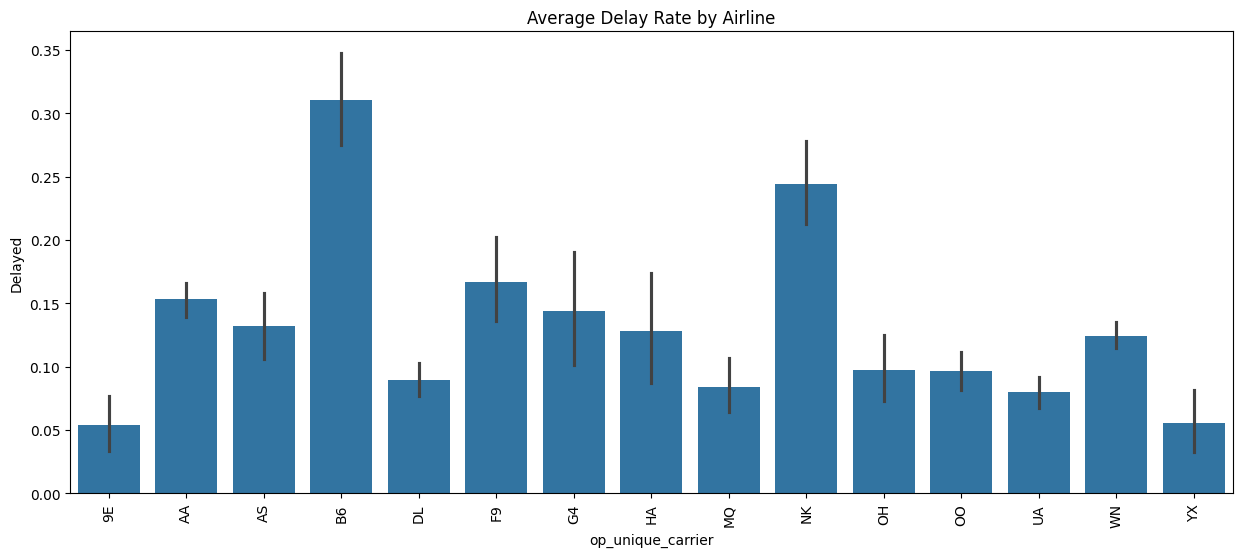

In [26]:
plt.figure(figsize=(15,6))

sns.barplot(
    data=df,
    x='op_unique_carrier',
    y='Delayed',
    estimator=np.mean
)

plt.xticks(rotation=90)

plt.title("Average Delay Rate by Airline")

plt.show()

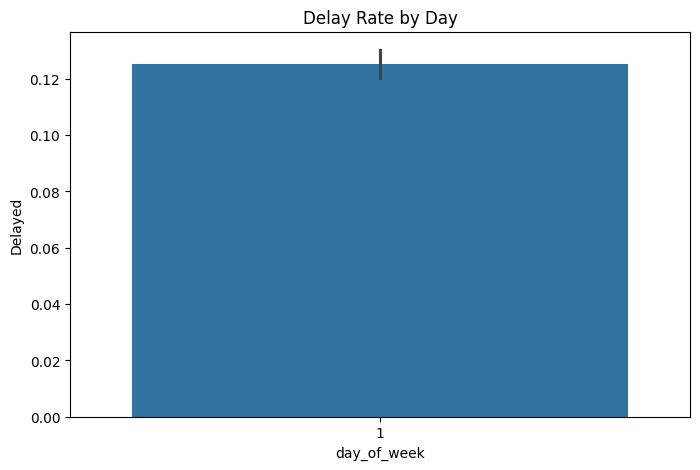

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='day_of_week',
    y='Delayed',
    estimator=np.mean
)

plt.title("Delay Rate by Day")

plt.show()

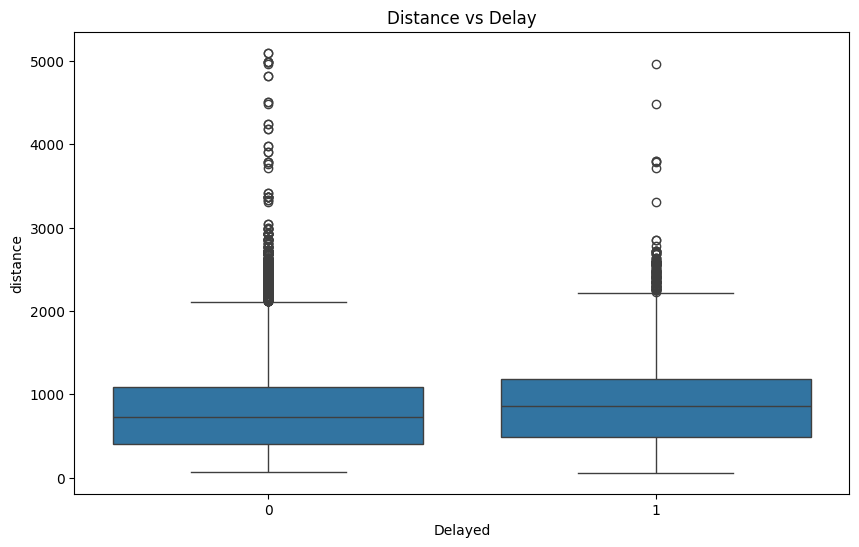

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Delayed',
    y='distance'
)

plt.title("Distance vs Delay")

plt.show()

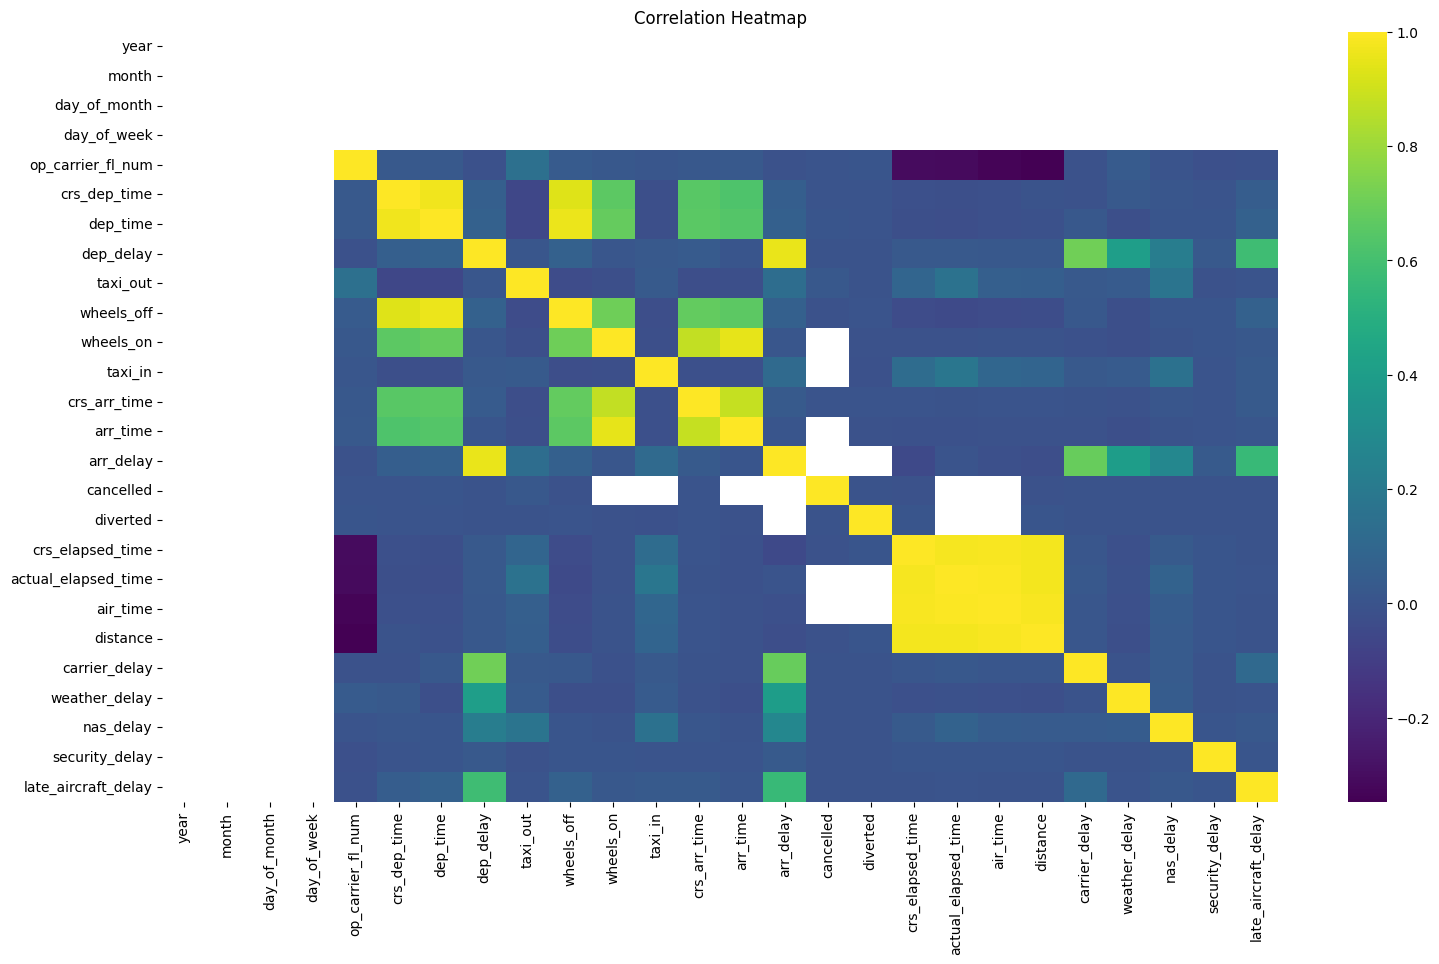

In [29]:
plt.figure(figsize=(18,10))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    cmap='viridis',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

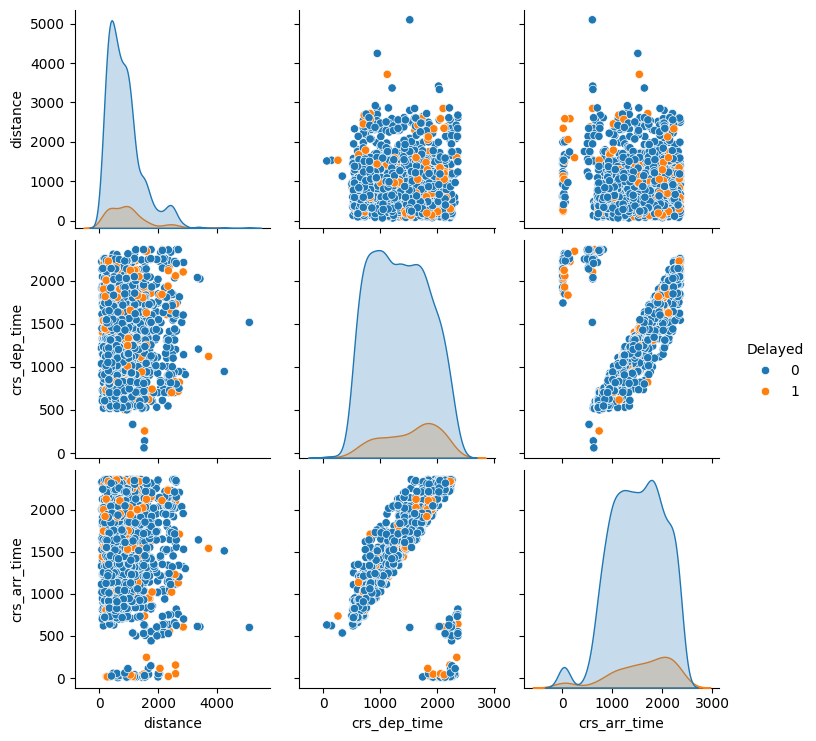

In [30]:
sample_df = df.sample(2000, random_state=42)

sns.pairplot(
    sample_df[
        [
            'distance',
            'crs_dep_time',
            'crs_arr_time',
            'Delayed'
        ]
    ],
    hue='Delayed'
)

plt.show()

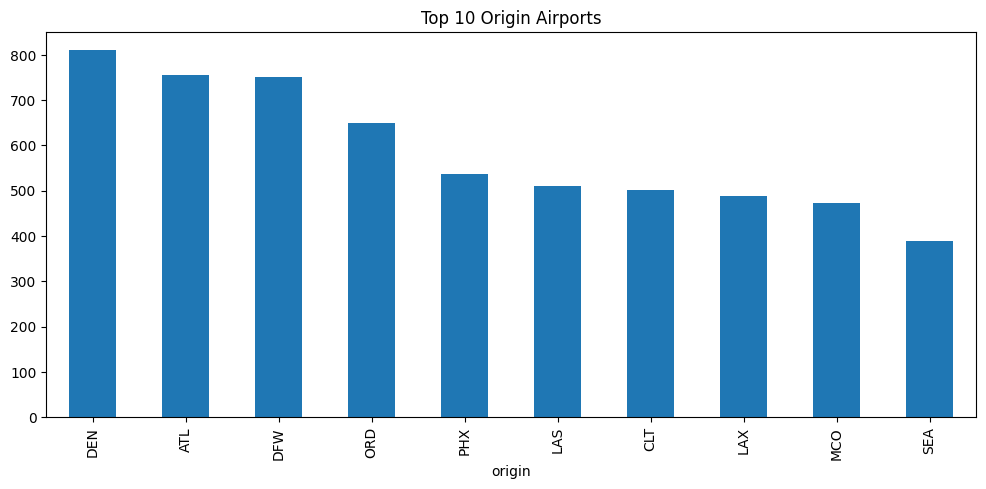

In [31]:
plt.figure(figsize=(12,5))

df['origin'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Origin Airports")

plt.show()

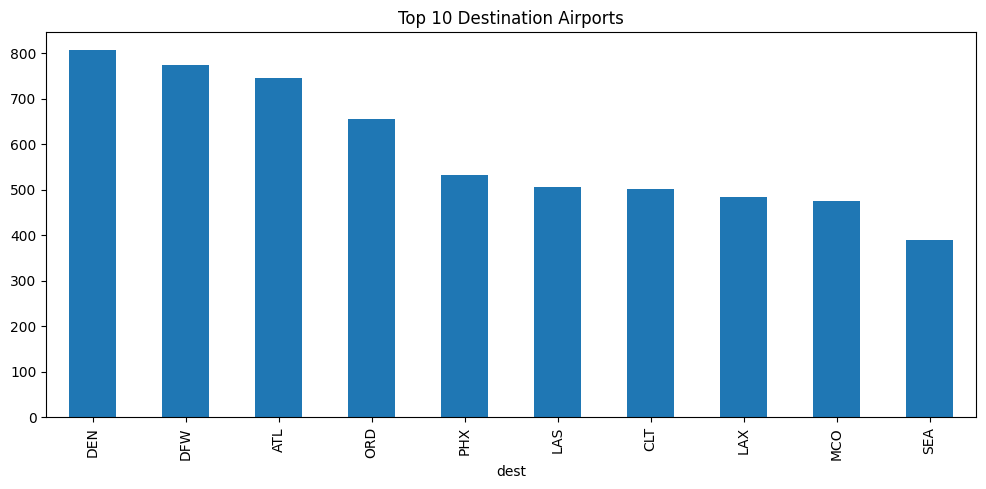

In [32]:
plt.figure(figsize=(12,5))

df['dest'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Destination Airports")

plt.show()

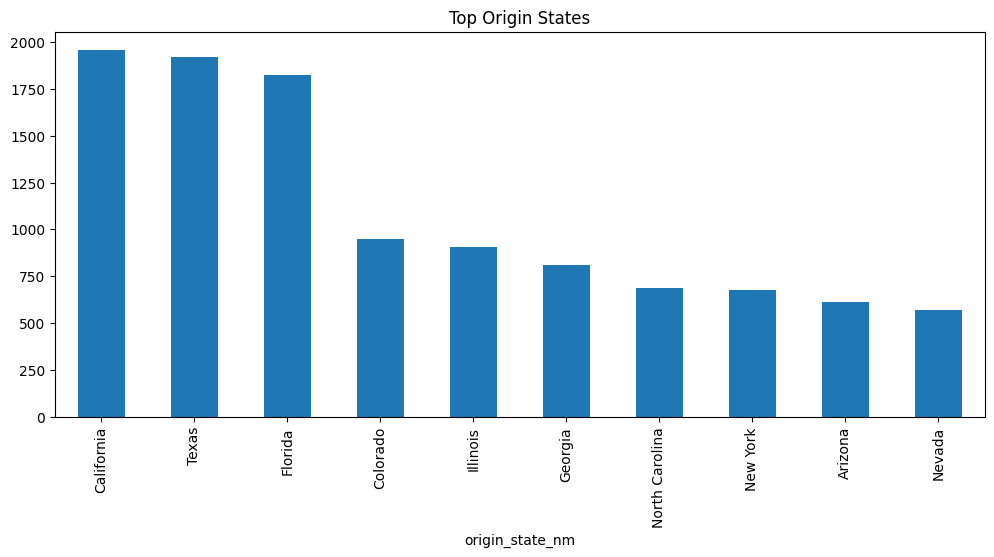

In [33]:
plt.figure(figsize=(12,5))

df['origin_state_nm'].value_counts().head(10).plot(kind='bar')

plt.title("Top Origin States")

plt.show()

After generating the plots, write observations based on your actual outputs rather than generic statements.

For example:

The target variable distribution indicates whether the dataset is balanced or imbalanced.
Flight traffic is concentrated in certain months, airlines, and airports.
Flight distances are right-skewed, with many short- and medium-haul flights.
Distance contains outliers, representing long-haul routes.
Some airlines have noticeably higher average delay rates than others.
Delay rates vary across months and days of the week, suggesting seasonal and operational effects.

Avoid writing conclusions that don't match your graphs.

In [34]:
df_clean = df.copy()

In [35]:
missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": round(df_clean.isnull().mean()*100,2)
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
cancellation_code,17037,99.89
actual_elapsed_time,25,0.15
arr_delay,25,0.15
air_time,25,0.15
arr_time,19,0.11
wheels_on,19,0.11
taxi_in,19,0.11
wheels_off,17,0.10
taxi_out,17,0.10
dep_delay,15,0.09


In [36]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [37]:
df_clean.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (17055, 36)


In [38]:
leakage_columns = [
    'dep_delay',
    'arr_delay',
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay',
    'actual_elapsed_time',
    'air_time',
    'wheels_off',
    'wheels_on',
    'taxi_out',
    'taxi_in',
    'dep_time',
    'arr_time',
    "op_carrier_fl_num"
]

df_clean.drop(columns=leakage_columns, inplace=True)

In [39]:
df_clean.drop(columns=['cancellation_code'], inplace=True)

print("Cancellation Code removed.")

Cancellation Code removed.


In [40]:
df_clean['fl_date'] = pd.to_datetime(df_clean['fl_date'])

df_clean['flight_year'] = df_clean['fl_date'].dt.year
df_clean['flight_month'] = df_clean['fl_date'].dt.month
df_clean['flight_day'] = df_clean['fl_date'].dt.day
df_clean['flight_dayofweek'] = df_clean['fl_date'].dt.dayofweek
df_clean['flight_week'] = df_clean['fl_date'].dt.isocalendar().week.astype(int)

print("Date features created.")

Date features created.


In [41]:
df_clean.drop(columns=['fl_date'], inplace=True)

In [42]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
distance,1
diverted,1
cancelled,1
crs_elapsed_time,1
year,0
month,0
day_of_month,0
origin_city_name,0
origin,0
op_unique_carrier,0


In [43]:
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

In [44]:
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

In [45]:
df_clean.isnull().sum().sum()

np.int64(0)

In [46]:
df_clean.head()

,year,month,day_of_month,day_of_week,op_unique_carrier,origin,origin_city_name,origin_state_nm,dest,dest_city_name,...,cancelled,diverted,crs_elapsed_time,distance,Delayed,flight_year,flight_month,flight_day,flight_dayofweek,flight_week
0,2024,1,1,1,9E,JFK,"New York, NY",New York,DTW,"Detroit, MI",...,0.0,0.0,136.0,509.0,0,2024,1,1,0,1
1,2024,1,1,1,9E,MSP,"Minneapolis, MN",Minnesota,CLE,"Cleveland, OH",...,0.0,0.0,130.0,622.0,0,2024,1,1,0,1
2,2024,1,1,1,9E,JFK,"New York, NY",New York,RIC,"Richmond, VA",...,0.0,0.0,106.0,288.0,0,2024,1,1,0,1
3,2024,1,1,1,9E,RIC,"Richmond, VA",Virginia,JFK,"New York, NY",...,0.0,0.0,111.0,288.0,0,2024,1,1,0,1
4,2024,1,1,1,9E,DTW,"Detroit, MI",Michigan,MKE,"Milwaukee, WI",...,0.0,0.0,79.0,237.0,0,2024,1,1,0,1


In [47]:
df_clean['departure_hour'] = (df_clean['crs_dep_time'] // 100).astype(int)

df_clean[['crs_dep_time', 'departure_hour']].head()

,crs_dep_time,departure_hour
0,1252,12
1,1015,10
2,1415,14
3,1650,16
4,1015,10


In [48]:
df_clean['arrival_hour'] = (df_clean['crs_arr_time'] // 100).astype(int)

df_clean[['crs_arr_time', 'arrival_hour']].head()

,crs_arr_time,arrival_hour
0,1508,15
1,1325,13
2,1601,16
3,1841,18
4,1034,10


In [49]:
def time_period(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"

df_clean['departure_period'] = df_clean['departure_hour'].apply(time_period)

df_clean[['departure_hour', 'departure_period']].head()

,departure_hour,departure_period
0,12,Afternoon
1,10,Morning
2,14,Afternoon
3,16,Afternoon
4,10,Morning


In [50]:
df_clean['is_weekend'] = df_clean['day_of_week'].apply(
    lambda x: 1 if x in [6, 7] else 0
)

df_clean[['day_of_week', 'is_weekend']].head()

,day_of_week,is_weekend
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [51]:
df_clean['route'] = (
    df_clean['origin'] + "_" + df_clean['dest']
)

df_clean[['origin', 'dest', 'route']].head()

,origin,dest,route
0,JFK,DTW,JFK_DTW
1,MSP,CLE,MSP_CLE
2,JFK,RIC,JFK_RIC
3,RIC,JFK,RIC_JFK
4,DTW,MKE,DTW_MKE


In [52]:
df_clean['distance_category'] = pd.cut(
    df_clean['distance'],
    bins=[0, 500, 1500, np.inf],
    labels=['Short', 'Medium', 'Long']
)

df_clean[['distance', 'distance_category']].head()

,distance,distance_category
0,509.0,Medium
1,622.0,Medium
2,288.0,Short
3,288.0,Short
4,237.0,Short


In [53]:
df_clean['duration_category'] = pd.cut(
    df_clean['crs_elapsed_time'],
    bins=[0, 120, 240, np.inf],
    labels=['Short', 'Medium', 'Long']
)

df_clean[['crs_elapsed_time', 'duration_category']].head()

,crs_elapsed_time,duration_category
0,136.0,Medium
1,130.0,Medium
2,106.0,Short
3,111.0,Short
4,79.0,Short


In [54]:
new_features = [
    'departure_hour',
    'arrival_hour',
    'departure_period',
    'is_weekend',
    'route',
    'distance_category',
    'duration_category'
]

df_clean[new_features].head()

,departure_hour,arrival_hour,departure_period,is_weekend,route,distance_category,duration_category
0,12,15,Afternoon,0,JFK_DTW,Medium,Medium
1,10,13,Morning,0,MSP_CLE,Medium,Medium
2,14,16,Afternoon,0,JFK_RIC,Short,Short
3,16,18,Afternoon,0,RIC_JFK,Short,Short
4,10,10,Morning,0,DTW_MKE,Short,Short


In [55]:
df_model = df_clean.copy()

df_model.drop(columns="flight_year", inplace=True)

print(df_model.shape)

(17055, 29)


In [56]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17055 entries, 0 to 17054
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   year               17055 non-null  int64   
 1   month              17055 non-null  int64   
 2   day_of_month       17055 non-null  int64   
 3   day_of_week        17055 non-null  int64   
 4   op_unique_carrier  17055 non-null  object  
 5   origin             17055 non-null  object  
 6   origin_city_name   17055 non-null  object  
 7   origin_state_nm    17055 non-null  object  
 8   dest               17055 non-null  object  
 9   dest_city_name     17055 non-null  object  
 10  dest_state_nm      17055 non-null  object  
 11  crs_dep_time       17055 non-null  int64   
 12  crs_arr_time       17055 non-null  int64   
 13  cancelled          17055 non-null  float64 
 14  diverted           17055 non-null  float64 
 15  crs_elapsed_time   17055 non-null  float64 
 16  dist

In [57]:
X=df_model.drop("Delayed",axis=1)
y=df_model["Delayed"]

In [58]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [59]:
numerical_features = X_train.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object","category"]
).columns.tolist()

print("Numerical Features :",len(numerical_features))

print("Categorical Features :",len(categorical_features))

Numerical Features : 14
Categorical Features : 11


In [60]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [61]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            StandardScaler(),

            numerical_features

        ),

        (

            "cat",

            OneHotEncoder(

                handle_unknown="ignore"

            ),

            categorical_features

        )

    ]
)

In [62]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [63]:
print("Training Shape :",X_train_processed.shape)

print("Testing Shape :",X_test_processed.shape)

Training Shape : (13644, 5733)
Testing Shape : (3411, 5733)


In [64]:
import joblib

joblib.dump(

    preprocessor,

    "preprocessor.pkl"

)

print("Preprocessor Saved.")

Preprocessor Saved.


In [78]:
knn_clf=KNeighborsClassifier()
knn_clf.fit(X_train_processed,y_train)

KNeighborsClassifier()

In [79]:
y_pred=knn_clf.predict(X_test_processed)

In [80]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score,classification_report
acc_score=accuracy_score(y_test,y_pred)
pre_score=precision_score(y_test,y_pred)
rec_score=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
clf_report=classification_report(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_pred)

print("Accuracy Score:",acc_score)
print("Precision Score:",pre_score)
print("Recall Score:",rec_score)
print("F1 Score:",f1)
print("Confusion Matrix:",cm)
print("Classification Report:",clf_report)
print("ROC AUC Score:",roc_auc_score)

Accuracy Score: 0.8613309879800645
Precision Score: 0.3046875
Recall Score: 0.09219858156028368
F1 Score: 0.14156079854809436
Confusion Matrix: [[2899   89]
 [ 384   39]]
Classification Report:               precision    recall  f1-score   support

           0       0.88      0.97      0.92      2988
           1       0.30      0.09      0.14       423

    accuracy                           0.86      3411
   macro avg       0.59      0.53      0.53      3411
weighted avg       0.81      0.86      0.83      3411

ROC AUC Score: <function roc_auc_score at 0x7bb0a47b1d00>


In [81]:
joblib.dump(

    y.unique(),

    "target_labels.pkl"

)

['target_labels.pkl']

In [85]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [86]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}


In [87]:
best_knn = grid_search.best_estimator_

In [88]:
joblib.dump(

    best_knn,

    "flight_delay_model.pkl"

)

print("Model Saved Successfully.")

Model Saved Successfully.


In [ ]:
import joblib

dropdown_values = {
    "airlines": sorted(df_clean["op_unique_carrier"].dropna().unique().tolist()),
    "origins": sorted(df_clean["origin"].dropna().unique().tolist()),
    "origin_cities": sorted(df_clean["origin_city_name"].dropna().unique().tolist()),
    "origin_states": sorted(df_clean["origin_state_nm"].dropna().unique().tolist()),
    "destinations": sorted(df_clean["dest"].dropna().unique().tolist()),
    "destination_cities": sorted(df_clean["dest_city_name"].dropna().unique().tolist()),
    "destination_states": sorted(df_clean["dest_state_nm"].dropna().unique().tolist())
}

joblib.dump(dropdown_values, "dropdown_values.pkl")

print("Dropdown values saved successfully!")